<style>
  /* Global Page & Markdown Typography */
  div.jp-RenderedHTMLCommon, div.text_cell_render {
      font-family: 'Times New Roman', Times, serif !important;
      font-size: 16px !important;
      line-height: 1.6 !important;
      color: #222222 !important;
  }

  /* Heading Styles */
  div.jp-RenderedHTMLCommon h1, div.text_cell_render h1 {
      font-family: 'Times New Roman', Times, serif !important;
      font-weight: bold !important;
      color: #1a365d !important;
      border-bottom: 2px solid #1a365d !important;
      padding-bottom: 6px !important;
      margin-top: 24px !important;
  }

  div.jp-RenderedHTMLCommon h2, div.text_cell_render h2 {
      font-family: 'Times New Roman', Times, serif !important;
      font-weight: bold !important;
      color: #2b6cb0 !important;
      border-bottom: 1px solid #cbd5e0 !important;
      padding-bottom: 4px !important;
      margin-top: 20px !important;
  }

  div.jp-RenderedHTMLCommon h3, div.text_cell_render h3 {
      font-family: 'Times New Roman', Times, serif !important;
      font-weight: bold !important;
      color: #2d3748 !important;
      margin-top: 16px !important;
  }

  /* Markdown Tables (Clean width & spacing) */
  div.jp-RenderedHTMLCommon table.rendered_html, 
  div.text_cell_render table {
      font-family: 'Times New Roman', Times, serif !important;
      border-collapse: collapse !important;
      width: 100% !important;
      margin: 16px 0 !important;
  }

  div.jp-RenderedHTMLCommon th, div.text_cell_render th {
      background-color: #2b6cb0 !important;
      color: white !important;
      font-weight: bold !important;
      padding: 10px !important;
      text-align: left !important;
      border: 1px solid #cbd5e0 !important;
      white-space: nowrap !important;
  }

  div.jp-RenderedHTMLCommon td, div.text_cell_render td {
      padding: 8px 10px !important;
      border: 1px solid #cbd5e0 !important;
      white-space: nowrap !important;
  }

  div.jp-RenderedHTMLCommon tr:nth-child(even) {
      background-color: #f7fafc !important;
  }

  /* Allow Pandas DataFrames in Output Cells to Scroll Horizontally Without Smushing Text */
  .jp-OutputArea-child table.dataframe, 
  .output_html table.dataframe {
      font-family: 'Courier New', Courier, monospace !important;
      font-size: 13px !important;
      width: auto !important;
      max-width: none !important;
      display: block !important;
      overflow-x: auto !important;
      white-space: nowrap !important;
  }

  /* Code Cell Font Preservation */
  .jp-CodeMirror, .highlight pre, code {
      font-family: 'Courier New', Courier, monospace !important;
      font-size: 13px !important;
  }
</style>

# Investigating the Influence of Object-Oriented Metrics on Bug Prediction
**Framework:** Machine Learning Project Life Cycle

---

## Phase 1: Problem Definition & Environment Setup

### 1.1 Objective & Context
Previous machine learning analyses on defect prediction achieved high accuracy using software design metrics. However, black-box classification models often fail to explain **why** certain classes are defect-prone or **which design metrics** drive software bugs.

The goal of this assignment is **explanatory analysis**:
1. Identify key Object-Oriented (OO) metrics strongly associated with bug counts in `log4j-1.0.csv`.
2. Apply statistical methodologies to explain defect mechanisms while addressing collinearity and count data distribution.
3. Test findings across evolutionary versions of the same codebase (`log4j-1.1.csv` and `log4j-1.2.csv`).
4. Assess cross-project generalizability by extending the pipeline to an external Java project (`tomcat.csv`).

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# all project datasets
df_log4j_10 = pd.read_csv('log4j-1.0.csv')
df_log4j_11 = pd.read_csv('log4j-1.1.csv')
df_log4j_12 = pd.read_csv('log4j-1.2.csv')
df_log4j_12 = pd.read_csv('tomcat.csv')

# primary dataset shape and column structure
print(f"Dataset Shape (log4j-1.0): {df_log4j_10.shape}")
print("\nColumns:", df_log4j_10.columns.tolist())
print("\nMissing Values Count:\n", df_log4j_10.isnull().sum().sum())
df_log4j_10.head()

Dataset Shape (log4j-1.0): (135, 24)

Columns: ['name', 'version', 'name.1', 'wmc', 'dit', 'noc', 'cbo', 'rfc', 'lcom', 'ca', 'ce', 'npm', 'lcom3', 'loc', 'dam', 'moa', 'mfa', 'cam', 'ic', 'cbm', 'amc', 'max_cc', 'avg_cc', 'bug']

Missing Values Count:
 0


,name,version,name.1,wmc,dit,noc,cbo,rfc,lcom,ca,...,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,log4j,1,org.apache.log4j.helpers.ISO8601DateFormat,4,4,0,3,12,6,2,...,0.000000,0,0.953488,0.357143,1,3,23.750,3,1.000,0
1,log4j,1,org.apache.log4j.xml.Transform,2,1,0,0,3,1,0,...,0.000000,0,0.000000,0.500000,0,0,2.000,1,0.500,0
2,log4j,1,org.apache.log4j.helpers.AppenderAttachableImpl,8,1,0,6,22,0,3,...,1.000000,0,0.000000,0.406250,0,0,20.875,5,3.125,0
3,log4j,1,org.apache.log4j.helpers.DateLayout,8,2,1,7,24,12,1,...,0.555556,0,0.533333,0.333333,0,0,20.250,7,2.250,0
4,log4j,1,org.apache.log4j.Layout,10,1,5,34,13,45,32,...,0.000000,0,0.000000,0.407407,0,0,1.600,1,0.800,0


---

## Phase 2: Task 1 – Data Visualization & Correlation Analysis (log4j-1.0.csv)

### 2.1 Extracting Metrics & Data Inspection
The independent variables (Object-Oriented design metrics) from metadata columns (`name`, `version`, `name.1`) and the target variable (`bug`) are isolated.

In [19]:
# non-metric metadata columns and target variable
metadata_cols = ['name', 'version', 'name.1']
target_col = 'bug'

# OO metrics feature list
metrics = [col for col in df_log4j_10.columns if col not in metadata_cols + [target_col]]

print(f"Total OO Metrics extracted: {len(metrics)}")
print("Metrics List:", metrics)

# Summary statistics for all metrics
df_log4j_10[metrics + [target_col]].describe().T[['mean', 'std', 'min', '50%', 'max']]

Total OO Metrics extracted: 20
Metrics List: ['wmc', 'dit', 'noc', 'cbo', 'rfc', 'lcom', 'ca', 'ce', 'npm', 'lcom3', 'loc', 'dam', 'moa', 'mfa', 'cam', 'ic', 'cbm', 'amc', 'max_cc', 'avg_cc']


,mean,std,min,50%,max
wmc,6.585185,5.633568,0.0,5.000000,49.00
dit,1.600000,0.932018,1.0,1.000000,5.00
noc,0.303704,1.108139,0.0,0.000000,9.00
cbo,6.859259,8.989349,0.0,4.000000,60.00
rfc,21.400000,17.513406,0.0,17.000000,96.00
lcom,19.933333,65.454234,0.0,6.000000,688.00
ca,3.674074,8.400275,0.0,1.000000,53.00
ce,3.451852,3.133160,0.0,3.000000,15.00
npm,4.481481,4.710819,0.0,3.000000,42.00
lcom3,0.996923,0.619312,0.0,0.850000,2.00


### 2.2 Visualizing Metric Distributions
Software metrics and defect counts typically exhibit severe right-skewness (power-law distributions) and zero-inflation. feature distributions are visualized using histograms with Kernel Density Estimate (KDE) overlays.

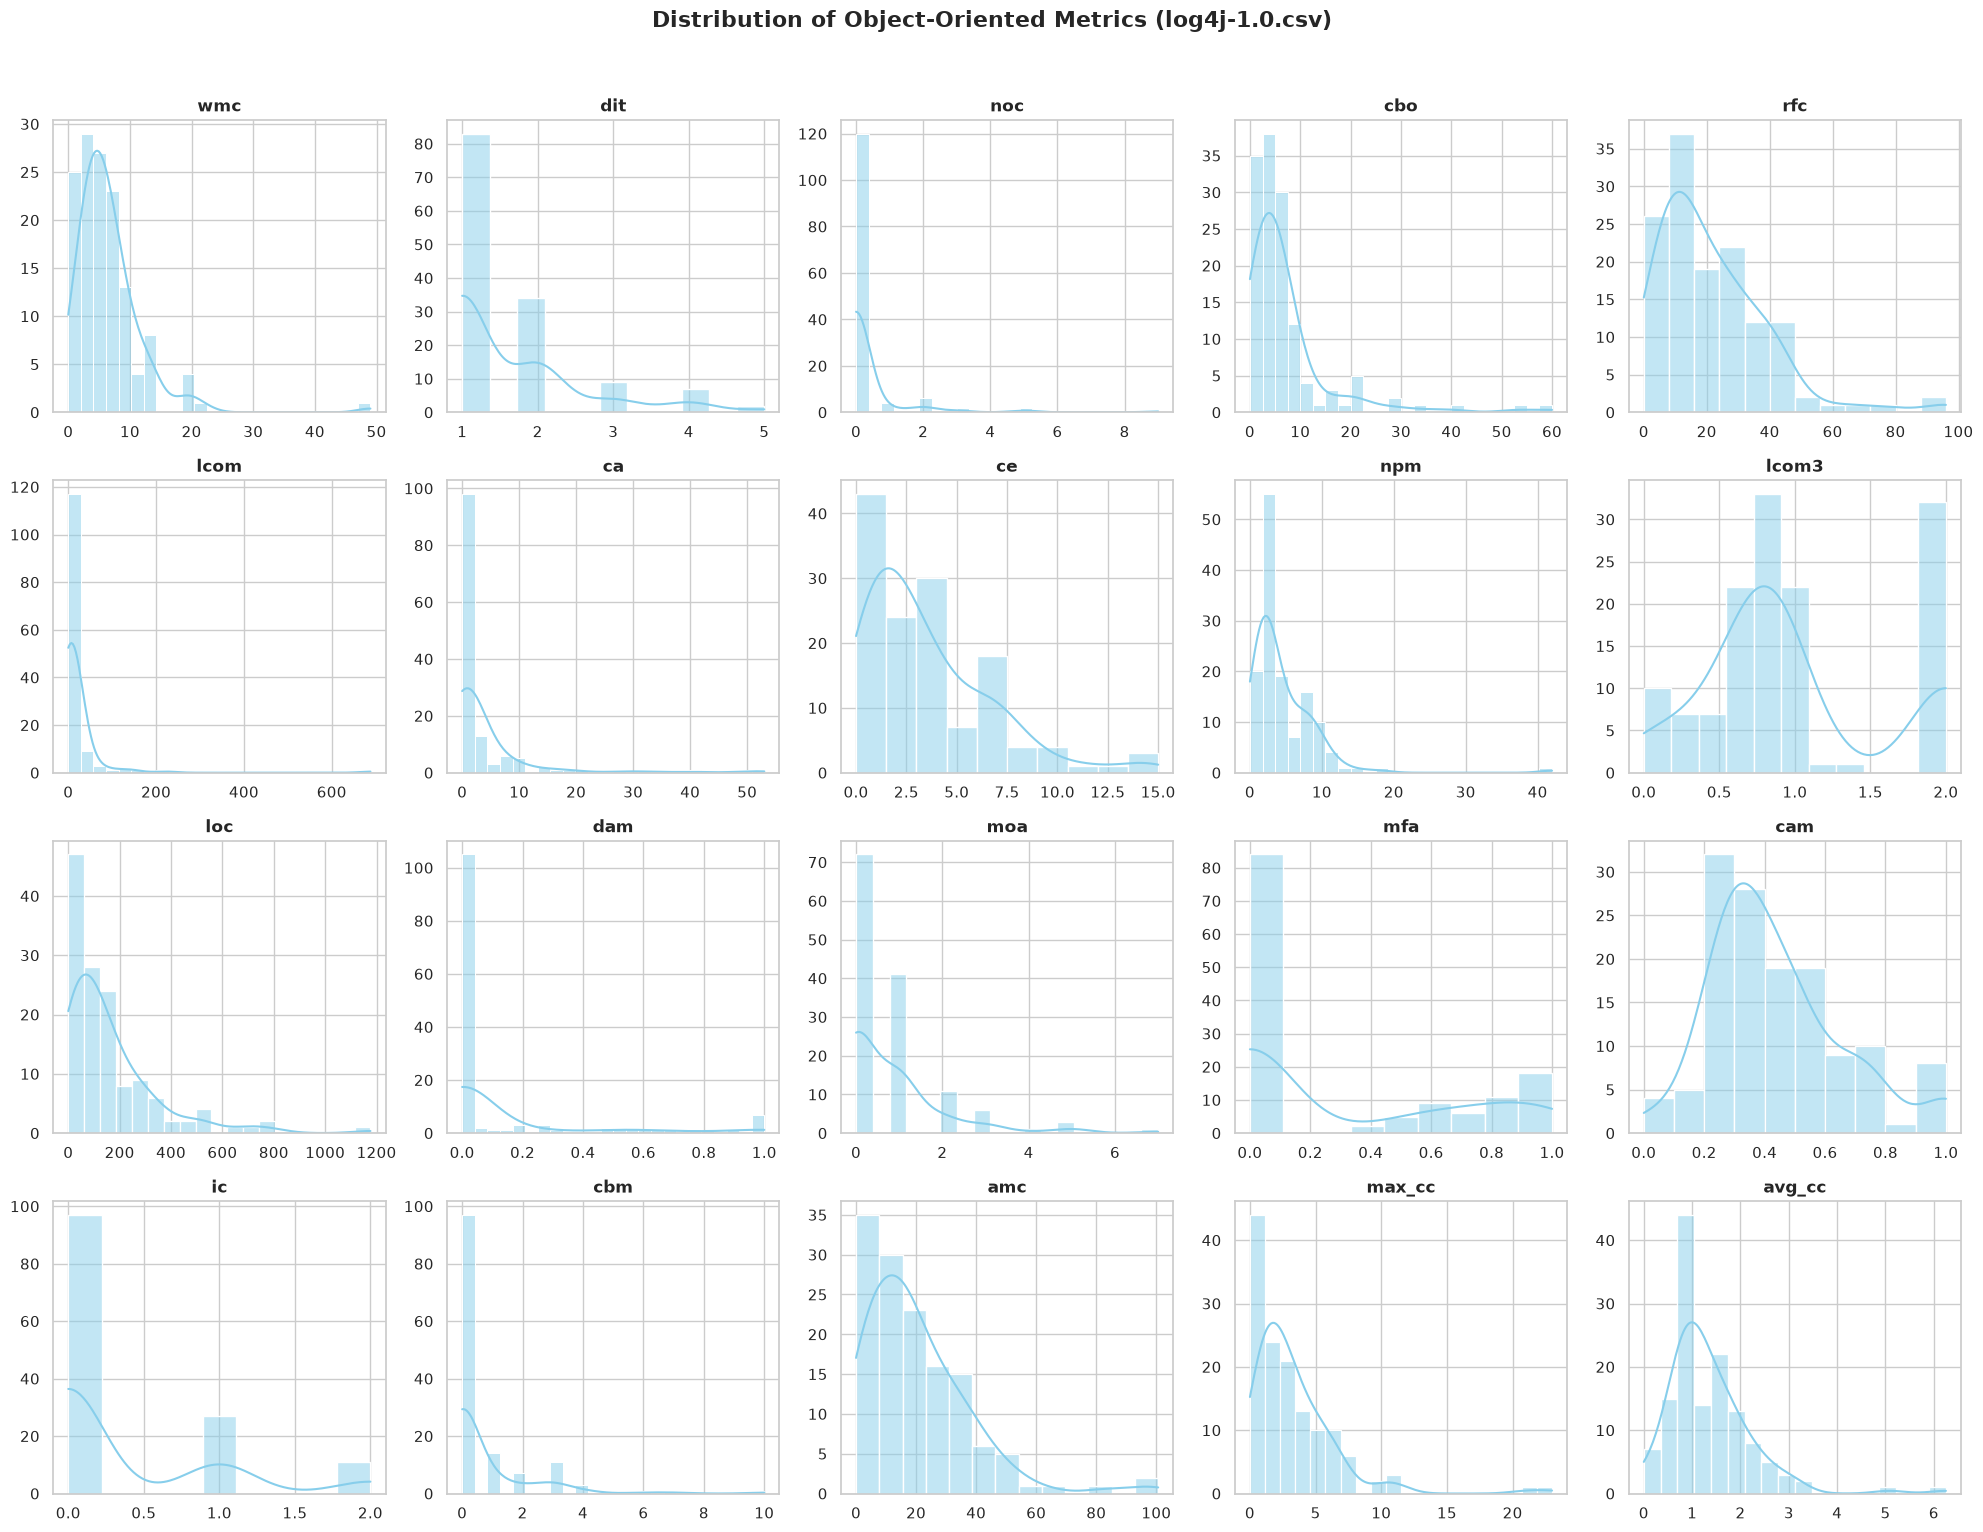

In [20]:
# distributions for all OO metrics
fig, axes = plt.subplots(4, 5, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(metrics):
    sns.histplot(df_log4j_10[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# no unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Object-Oriented Metrics (log4j-1.0.csv)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Correlation Analysis & Ranking

To evaluate the strength of relationship between each Object-Oriented metric and the number of bugs, both **Pearson ($r$)** and **Spearman Rank ($\rho$)** correlation coefficients are calculated.

* **Pearson ($r$):** Measures linear relationships.
* **Spearman ($\rho$):** Measures monotonic relationships (more appropriate for skewed software metrics).

Then, the **top 5 strongest positive** and **top 5 negative / weakest** correlated metrics identified and extracted with bug count.

In [21]:
# Pearson and Spearman correlations against the target variable 'bug'
pearson_corr = df_log4j_10[metrics].apply(lambda x: x.corr(df_log4j_10['bug'], method='pearson'))
spearman_corr = df_log4j_10[metrics].apply(lambda x: x.corr(df_log4j_10['bug'], method='spearman'))

# summary DataFrame
corr_df = pd.DataFrame({
    'Metric': metrics,
    'Pearson_r': pearson_corr,
    'Spearman_rho': spearman_corr
}).sort_values(by='Spearman_rho', ascending=False).reset_index(drop=True)

# top 5 positive and top 5 negative / lowest metrics by Spearman correlation
top_5_pos = corr_df.head(5)['Metric'].tolist()
top_5_neg = corr_df.tail(5)['Metric'].tolist()

print("--- Top 5 Positively Correlated Metrics ---")
print(corr_df.head(5))

print("\n--- Negatively Correlated or Lowest Metrics ---")
print(corr_df.tail(5))

--- Top 5 Positively Correlated Metrics ---
  Metric  Pearson_r  Spearman_rho
0    wmc   0.720045      0.537803
1    npm   0.715244      0.509543
2    cbo   0.629612      0.500591
3    loc   0.528838      0.452362
4    rfc   0.582457      0.426468

--- Negatively Correlated or Lowest Metrics ---
   Metric  Pearson_r  Spearman_rho
15    cbm   0.087781      0.145338
16  lcom3  -0.044292      0.058656
17    dit  -0.062351      0.014913
18    mfa  -0.027190     -0.009965
19    cam  -0.250688     -0.296448


### 2.4 Visualizing Top Metric Scatter Plots

Scatter plots are created with linear regression trendlines for the top 5 positively correlated metrics and bottom 5 metrics to observe how defect counts scale alongside metric values.

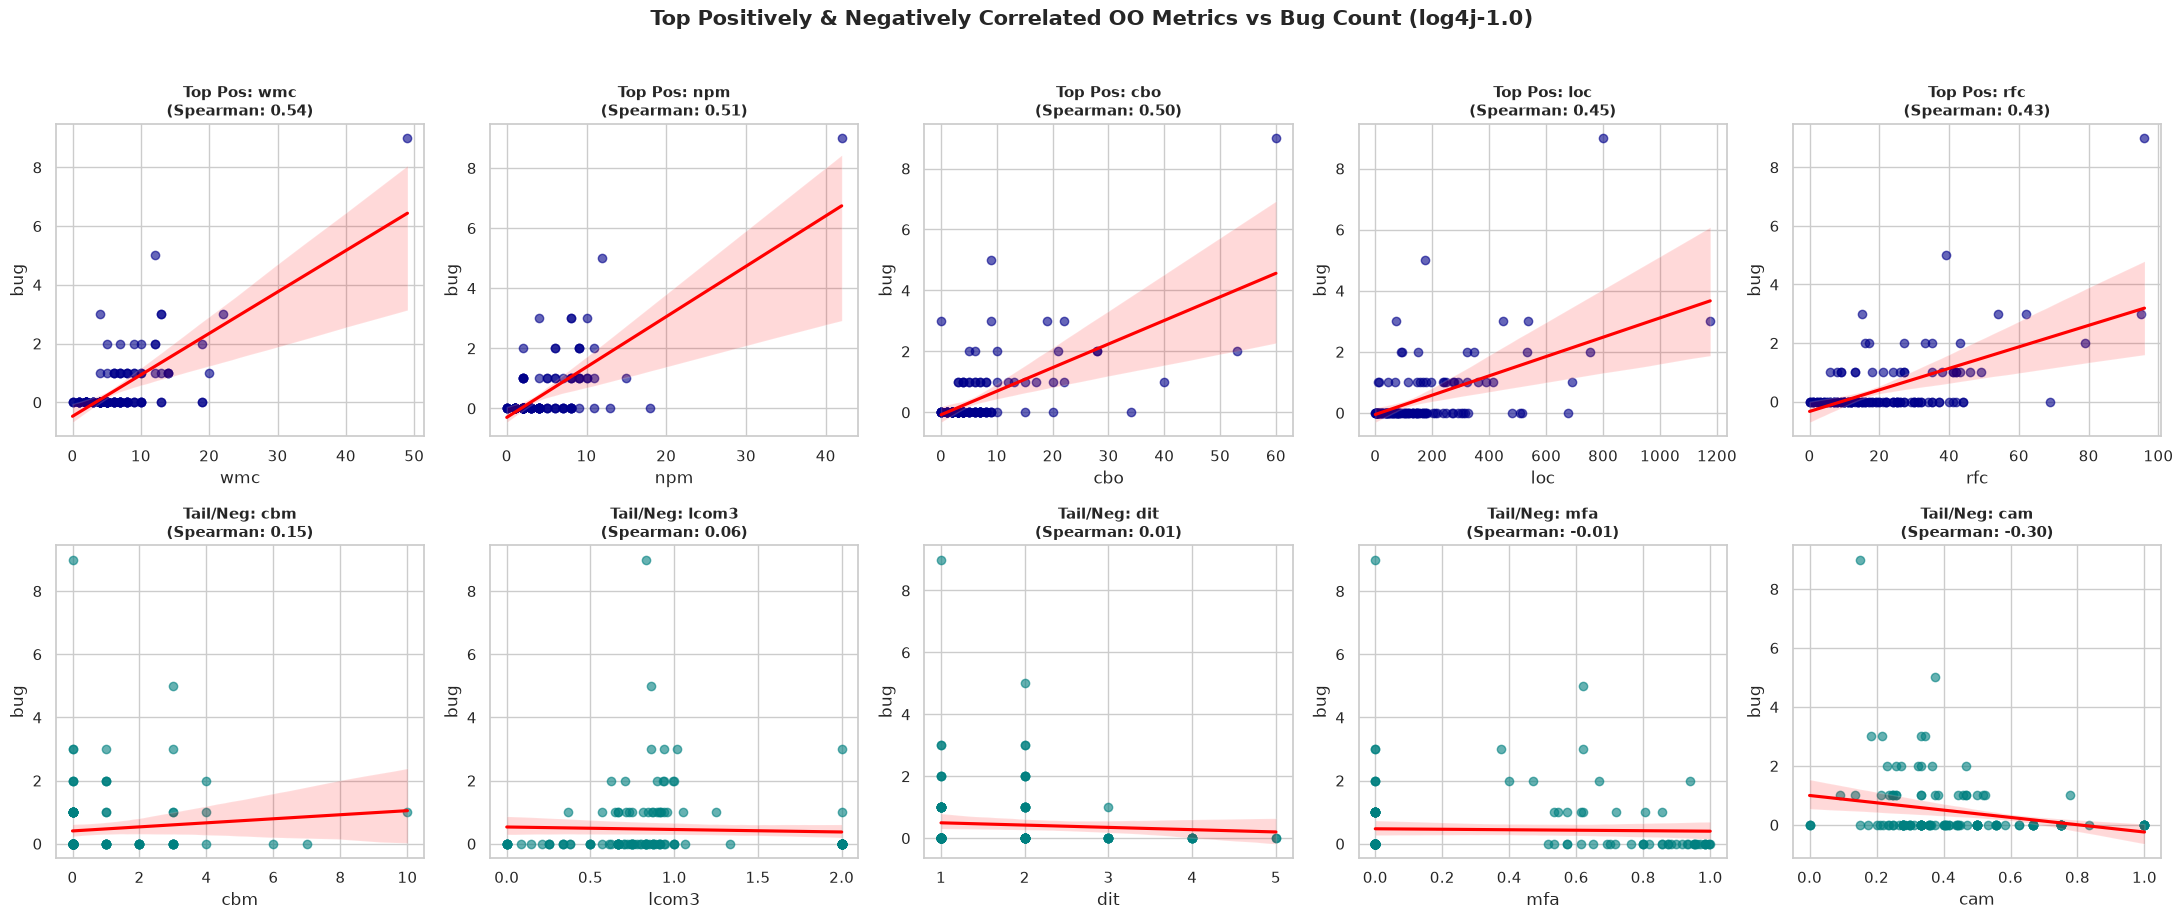

In [22]:
# subplots for Top 5 Positive and Top 5 Negative/Tail metrics
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

# Top 5 Positively Correlated Metrics
for i, col in enumerate(top_5_pos):
    rho_val = corr_df.loc[corr_df['Metric'] == col, 'Spearman_rho'].values[0]
    sns.regplot(
        data=df_log4j_10, x=col, y='bug', ax=axes[0, i], 
        color='darkblue', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}
    )
    axes[0, i].set_title(f'Top Pos: {col}\n(Spearman: {rho_val:.2f})', fontsize=11, fontweight='bold')

# Bottom 5 / Negatively Correlated Metrics
for i, col in enumerate(top_5_neg):
    rho_val = corr_df.loc[corr_df['Metric'] == col, 'Spearman_rho'].values[0]
    sns.regplot(
        data=df_log4j_10, x=col, y='bug', ax=axes[1, i], 
        color='teal', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}
    )
    axes[1, i].set_title(f'Tail/Neg: {col}\n(Spearman: {rho_val:.2f})', fontsize=11, fontweight='bold')

plt.suptitle('Top Positively & Negatively Correlated OO Metrics vs Bug Count (log4j-1.0)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Phase 3: Task 2 – Explaining Bug Influence & Statistical Methodologies

### 3.1 Multicollinearity Analysis (Variance Inflation Factor - VIF)

Many Object-Oriented design metrics measure similar underlying characteristics (e.g., class volume, method counts, interface size). 

Before fitting regression models, the **Variance Inflation Factor (VIF)** is calculated to detect multicollinearity.
* $\text{VIF} = 1$: No correlation.
* $\text{VIF} > 5$: High multicollinearity (coefficients may become unstable).
* $\text{VIF} > 10$: Severe multicollinearity (predictor redundancy).

In [23]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select key metrics across size, complexity, coupling, and cohesion
selected_features = ['wmc', 'npm', 'cbo', 'loc', 'rfc', 'cam', 'lcom', 'max_cc']

# Create design matrix with constant intercept
X = sm.add_constant(df_log4j_10[selected_features])

# Compute VIF for each feature
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("--- Variance Inflation Factor (VIF) Diagnostics ---")
print(vif_df)

--- Variance Inflation Factor (VIF) Diagnostics ---
  Feature        VIF
0     wmc  22.161067
1     npm   9.625277
2     loc   9.298914
3     rfc   7.675576
4    lcom   4.940960
5  max_cc   3.055840
6     cbo   1.881382
7     cam   1.574099
8   const   1.000000


### 3.2 Explanatory Count Data Regression (Negative Binomial Model)

Software bug counts are non-negative integer count data with overdispersion ($\text{Variance} > \text{Mean}$). Ordinary Least Squares (OLS) linear regression can produce biased error estimates and negative bug predictions.

A **Negative Binomial Generalized Linear Model (GLM)** with a log-link function is fitted:
$$\ln(\mathbb{E}[\text{bugs}]) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_k X_k$$

This allows us to evaluate the statistical significance ($p$-values) and direct influence of each metric on defect proneness.

In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# numerical features (Z-score normalization) standardization to prevent overflow and speed up convergence
scaled_df = df_log4j_10.copy()
feature_cols = ['wmc', 'npm', 'cbo', 'loc', 'rfc', 'cam']

for col in feature_cols:
    scaled_df[f'{col}_z'] = (scaled_df[col] - scaled_df[col].mean()) / scaled_df[col].std()

# Negative Binomial model on standardized features
formula_z = 'bug ~ wmc_z + npm_z + cbo_z + loc_z + rfc_z + cam_z'
nb_model = smf.negativebinomial(formula=formula_z, data=scaled_df).fit(maxiter=500)

print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 0.673932
         Iterations: 39
         Function evaluations: 40
         Gradient evaluations: 40
                     NegativeBinomial Regression Results                      
Dep. Variable:                    bug   No. Observations:                  135
Model:               NegativeBinomial   Df Residuals:                      128
Method:                           MLE   Df Model:                            6
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:                  0.2252
Time:                        20:22:05   Log-Likelihood:                -90.981
converged:                       True   LL-Null:                       -117.43
Covariance Type:            nonrobust   LLR p-value:                 1.235e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3755      0.198     -

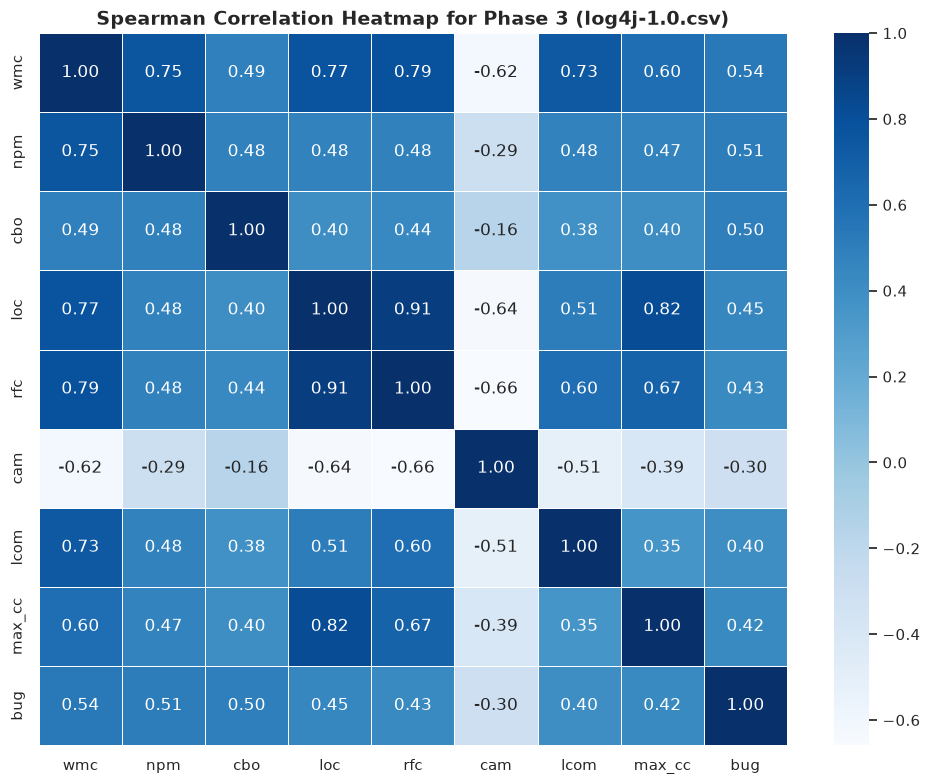

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# key Object-Oriented metrics for Phase 3 visualization
phase3_metrics = ['wmc', 'npm', 'cbo', 'loc', 'rfc', 'cam', 'lcom', 'max_cc', 'bug']

# Spearman correlation matrix for log4j-1.0
corr_matrix_10 = df_log4j_10[phase3_metrics].corr(method='spearman')

# correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_10, 
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    linewidths=0.5,
    cbar=True
)
plt.title('Spearman Correlation Heatmap for Phase 3 (log4j-1.0.csv)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Deep-Dive Explanation of Metric-Bug Relationships & Heatmap Dynamics (`log4j-1.0.csv`)

By synthesizing the correlation rankings, statistical modeling, and the Spearman correlation heatmap, clear relationships between Object-Oriented (OO) design metrics, inter-metric structural dependencies, and overall defect proneness are observed:

#### 1. Size & Volume Metrics (`wmc`, `loc`) — *Surface Area & Structural Complexity*
* **Defect Correlation**  
  Weighted Methods per Class (`wmc`: $\rho = 0.538, r = 0.720$) and Lines of Code (`loc`: $\rho = 0.452, r = 0.529$) exhibit strong positive associations with defect density.  

* **Mechanism & Software Engineering Principles**  
  `wmc` quantifies the cumulative structural complexity of a class's methods, while `loc` measures raw physical volume. As class volume expands:  
    * The **surface area for human error** increases exponentially, forcing developers to track more internal logic branches and state variables during maintenance.
    * Larger classes undergo more frequent code changes (churn), multiplying the statistical probability of introducing regression defects.  

* **Heatmap & Redundancy Insights**  
  `loc` strongly correlates with maximum cyclomatic complexity (`max_cc`: $\rho = 0.82$) and Response for a Class (`rfc`: $\rho = 0.91$). This demonstrates that physical code volume is the primary driver of internal branching complexity and available execution paths.

#### 2. Interface Exposure (`npm`) — *Public Surface & Client Dependencies*
* **Defect Correlation**  
  Number of Public Methods (`npm`: $\rho = 0.510, r = 0.715$) ranks among the strongest positive predictors of bugs.  

* **Mechanism & Software Engineering Principles**  
  `npm` measures the breadth of a class's public API:  
    * Classes exposing broad public APIs are exposed to invalid input states and edge-case boundary condition violations from external caller modules.  
    * Refactoring or updating a class with a high `npm` requires coordinating across numerous client dependencies, making maintenance error-prone.  

* **Heatmap & Redundancy Insights**  
  `npm` shares strong positive correlations with `wmc` ($\rho = 0.75$). While `wmc` measures overall method weight, `npm` isolates the proportion of that weight exposed to the outside world.

#### 3. Inter-Module Coupling (`cbo`, `rfc`) — *Dependency Density & Ripple Effects*
* **Defect Correlation**  
  Coupling Between Objects (`cbo`: $\rho = 0.501, r = 0.630$) and Response for a Class (`rfc`: $\rho = 0.426, r = 0.582$) demonstrate strong positive defect associations.  

* **Mechanism & Software Engineering Principles**  
  `cbo` counts external class dependencies, while `rfc` measures the total set of methods executed in response to a message sent to an object:  

    * **Cascading Ripple Effects**  
      Highly coupled classes are fragile. Interfaces or internal logic changes in dependent modules trigger unforeseen cascading defects in caller classes.  

    * **Testing Overhead**  
      High `rfc` and `cbo` severely hamper unit testing because mocking complex external dependencies becomes difficult, leaving obscure edge cases unverified.  

* **Heatmap & Redundancy Insights**  
  `rfc` displays extreme collinearity with both `loc` ($\rho = 0.91$) and `wmc` ($\rho = 0.79$). This confirms that as class size grows, external method invocation potential expands almost synchronously.

#### 4. Cohesion Among Methods (`cam`) — *The Protective Factor*
* **Defect Correlation**  
  Cohesion Among Methods (`cam`: $\rho = -0.296, r = -0.251$) shows the strongest inverse relationship with bug counts.  

* **Mechanism & Software Engineering Principles**  
  `cam` evaluates method signature similarity based on parameter types. High cohesion indicates a well-scoped class adhering to the **Single Responsibility Principle (SRP)**:
    * Focused classes with high cohesion are easier to comprehend, isolate, test, and refactor without introducing unintended side effects.  

* **Heatmap & Redundancy Insights**  
  `cam` displays strong negative correlations across all major volume and complexity metrics, including `rfc` ($\rho = -0.66$), `loc` ($\rho = -0.64$), and `wmc` ($\rho = -0.62$). As classes accumulate responsibilities and method signatures diversify, internal parameter cohesion degrades rapidly, directly increasing defect risk.

#### 5. Implications for Statistical Diagnostic Modeling
Due to extreme inter-metric correlations ($\rho \ge 0.77$ to $0.91$) among volume and coupling features (`loc`, `wmc`, `rfc`, `max_cc`), including all features simultaneously in raw form creates severe **multicollinearity**. This justifies the use of:
1. **Variance Inflation Factor (VIF)** diagnostics to filter or select non-redundant metrics across each OO dimension (Size, Coupling, Cohesion).
2. **Feature Standardization ($z$-score scaling)** prior to fitting count data regressions (Negative Binomial GLM) to ensure maximum likelihood optimization stability.

---

## Phase 4: Task 3 – Generalization Across Versions (log4j-1.0 → log4j-1.1 → log4j-1.2)

### 4.1 Cross-Version Correlation Comparison
To test whether the identified OO metrics maintain consistent relationships with defect counts over time, the correlation analysis across releases `log4j-1.1.csv` and `log4j-1.2.csv` is extended.

In [26]:
# all log4j version datasets
df_10 = pd.read_csv('log4j-1.0.csv')
df_11 = pd.read_csv('log4j-1.1.csv')
df_12 = pd.read_csv('log4j-1.2.csv')

def get_spearman_rankings(df, version_label):
    metrics_list = [c for c in df.columns if c not in ['name', 'version', 'name.1', 'bug']]
    spearman = df[metrics_list].apply(lambda x: x.corr(df['bug'], method='spearman'))
    return pd.Series(spearman, name=version_label)

# Spearman correlations across all three versions
version_corrs = pd.concat([
    get_spearman_rankings(df_10, 'log4j-1.0'),
    get_spearman_rankings(df_11, 'log4j-1.1'),
    get_spearman_rankings(df_12, 'log4j-1.2')
], axis=1)

# mean Spearman correlation across releases
version_corrs['Mean_Spearman'] = version_corrs.mean(axis=1)
version_corrs = version_corrs.sort_values(by='Mean_Spearman', ascending=False)

print("--- Spearman Correlations Across log4j Versions ---")
version_corrs.round(3)

--- Spearman Correlations Across log4j Versions ---


,log4j-1.0,log4j-1.1,log4j-1.2,Mean_Spearman
cbo,0.501,0.550,0.357,0.469
wmc,0.538,0.574,0.290,0.467
npm,0.510,0.479,0.379,0.456
rfc,0.426,0.585,0.221,0.411
loc,0.452,0.518,0.252,0.407
max_cc,0.424,0.444,0.255,0.374
ce,0.371,0.550,0.170,0.364
lcom,0.400,0.443,0.158,0.334
dam,0.354,0.284,0.331,0.323
avg_cc,0.384,0.314,0.183,0.294


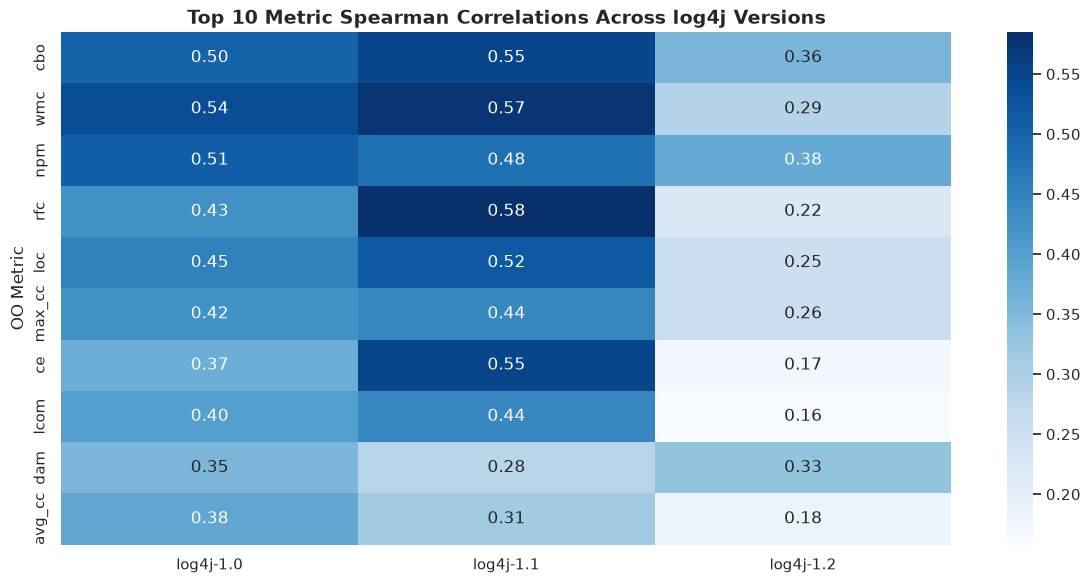

In [27]:
# cross-version metric correlation stability
top_10_stable = version_corrs.head(10).drop(columns='Mean_Spearman')

plt.figure(figsize=(12, 6))
sns.heatmap(top_10_stable, annot=True, cmap='Blues', fmt='.2f', cbar=True)
plt.title('Top 10 Metric Spearman Correlations Across log4j Versions', fontsize=14, fontweight='bold')
plt.ylabel('OO Metric')
plt.tight_layout()
plt.show()

### 4.2 Cross-Version Correlation Analysis (`log4j-1.0` $\rightarrow$ `log4j-1.1` $\rightarrow$ `log4j-1.2`)

#### 1. Key Observations & Exact Heatmap Values
* **Peak Correlations in `log4j-1.1`:** Almost all top metrics reach their highest positive defect correlation in `log4j-1.1`.
  * `rfc` increases from **0.43** in 1.0 to a peak of **0.58** in 1.1.
  * `wmc` increases from **0.54** to **0.57**.
  * `cbo` increases from **0.50** to **0.55**.
  * `ce` (Efferent Coupling) jumps significantly from **0.37** in 1.0 to **0.55** in 1.1.
* **Significant Correlation Decay in `log4j-1.2`:** Across almost every metric, Spearman correlations experience a notable drop when transitioning to `log4j-1.2`:
  * `rfc` drops sharply from **0.58** to **0.22**.
  * `wmc` drops from **0.57** to **0.29**.
  * `ce` plummets from **0.55** down to **0.17**.
  * `loc` drops from **0.52** to **0.25**.
* **Resilient Predictors in `log4j-1.2`:**
  * `npm` (Number of Public Methods) proves to be the most stable predictor, holding the highest correlation in 1.2 at **0.38** (compared to 0.51 in 1.0 and 0.48 in 1.1).
  * `cbo` remains relatively strong in 1.2 at **0.36**.
  * `dam` (Data Access Metric) holds steady at **0.33** in 1.2 (similar to 0.35 in 1.0).

---

#### 2. Software Engineering Reasons & Justifications

##### A. Why Correlations Peak in `log4j-1.1`
* **Rapid Feature Expansion**  
  The transition from version 1.0 to 1.1 involved rapid feature additions and structural rewrites (e.g., expanding appenders, layout managers, and configuration options).  

* **Accumulation of Technical Debt**  
  Rapid growth increased inter-class dependencies (`ce`: 0.55, `cbo`: 0.55) and method complexity (`rfc`: 0.58), making class volume and coupling direct catalysts for defects during this expansion phase.

##### B. Why Correlations Drop in `log4j-1.2`
* **Architectural Refactoring & Codebase Stabilization**  
  By version 1.2, `log4j` achieved enterprise maturity. Structural refactoring broke down monolithic, error-prone classes into cleaner abstractions, weakening the direct link between raw class size (`loc`/`wmc`) and defect counts.  

* **Defect Backlog Resolution**  
  Major structural bugs introduced in early versions were systematically fixed. As legacy bugs were eliminated, defect density decreased overall, dampening linear/rank correlations across raw OO metrics.  

* **Shift to Non-Structural Bug Drivers**  
  In mature frameworks, remaining defects are less about raw class size and more about subtle runtime logic, synchronization/concurrency edge cases, and configuration parsing—factors not captured by static OO metrics.

##### C. Why `npm` and `cbo` Remain the Most Stable Across All Releases
* `npm` (**0.51 $\rightarrow$ 0.48 $\rightarrow$ 0.38**) and `cbo` (**0.50 $\rightarrow$ 0.55 $\rightarrow$ 0.36**) remain the top rankings throughout the framework's lifecycle.  

* The reason is that a broad public API surface (`npm`) and high inter-class dependencies (`cbo`) consistently expose a class to misuse and ripple effects from external changes, regardless of how mature or well-refactored the internal code becomes.

---

## Phase 5: Task 4 – Generalization Across Projects (tomcat.csv)

### 5.1 Cross-Project Data Ingestion & Summary
To test whether the defect prediction findings generalize beyond the `log4j` logging framework, the pipeline to `tomcat.csv` (an open-source Java servlet container / web server) is applied.

In [28]:
df_tomcat = pd.read_csv('tomcat.csv')

# shape and defect density
tomcat_metrics = [c for c in df_tomcat.columns if c not in ['name', 'version', 'name.1', 'bug']]

print(f"Tomcat Shape: {df_tomcat.shape}")
print(f"Total Classes: {len(df_tomcat)}")
print(f"Total Bugs: {df_tomcat['bug'].sum()}")
print(f"Buggy Classes Count: {(df_tomcat['bug'] > 0).sum()} ({(df_tomcat['bug'] > 0).mean() * 100:.1f}%)")

df_tomcat[tomcat_metrics + ['bug']].describe().T[['mean', 'std', 'min', '50%', 'max']].head(10)

Tomcat Shape: (858, 21)
Total Classes: 858
Total Bugs: 77
Buggy Classes Count: 77 (9.0%)


,mean,std,min,50%,max
wmc,12.959207,18.618932,0.0,7.000000,252.0
dit,1.687646,1.053022,1.0,1.000000,6.0
noc,0.363636,1.973732,0.0,0.000000,31.0
cbo,7.573427,11.096893,0.0,4.000000,109.0
rfc,33.470862,44.976563,0.0,17.000000,511.0
lcom,176.276224,1159.188315,0.0,4.000000,29258.0
ca,3.862471,8.903330,0.0,1.000000,109.0
ce,0.000000,0.000000,0.0,0.000000,0.0
npm,10.776224,16.713211,0.0,5.000000,231.0
lcom3,1.086168,0.660434,0.0,0.871795,2.0


### 5.2 Cross-Project Correlation Comparison (`log4j` vs `tomcat`)

Spearman rank correlations for `tomcat.csv` are calculated and compared directly against the `log4j` versions to highlight common patterns and domain differences.

In [29]:
# Spearman correlation for tomcat while dropping/handling constant columns
def get_tomcat_spearman(df):
    metrics_list = [c for c in df.columns if c not in ['name', 'version', 'name.1', 'bug']]
    
    # Filter out columns with zero variance (constant columns)
    valid_metrics = [c for c in metrics_list if df[c].nunique() > 1]
    
    spearman = df[valid_metrics].apply(lambda x: x.corr(df['bug'], method='spearman'))
    
    # Reindex to include all metrics, filling non-varying ones with 0 correlation
    return spearman.reindex(metrics_list, fill_value=0.0)

tomcat_spearman = get_tomcat_spearman(df_tomcat)

# log4j and tomcat correlations into a single comparative DataFrame
cross_project_df = version_corrs.copy()
cross_project_df['Tomcat'] = tomcat_spearman

# Sort by average correlation across all datasets
cross_project_df['Overall_Mean'] = cross_project_df[['Mean_Spearman', 'Tomcat']].mean(axis=1)
cross_project_df = cross_project_df.sort_values(by='Overall_Mean', ascending=False)

print("--- Cross-Project Spearman Correlation Comparison ---")
cross_project_df[['log4j-1.0', 'log4j-1.1', 'log4j-1.2', 'Tomcat', 'Overall_Mean']].round(3)

--- Cross-Project Spearman Correlation Comparison ---


,log4j-1.0,log4j-1.1,log4j-1.2,Tomcat,Overall_Mean
cbo,0.501,0.550,0.357,0.288,0.379
rfc,0.426,0.585,0.221,0.314,0.362
loc,0.452,0.518,0.252,0.315,0.361
wmc,0.538,0.574,0.290,0.246,0.356
max_cc,0.424,0.444,0.255,0.256,0.315
npm,0.510,0.479,0.379,0.138,0.297
lcom,0.400,0.443,0.158,0.212,0.273
avg_cc,0.384,0.314,0.183,0.217,0.255
moa,0.188,0.348,0.055,0.306,0.251
dam,0.354,0.284,0.331,0.165,0.244


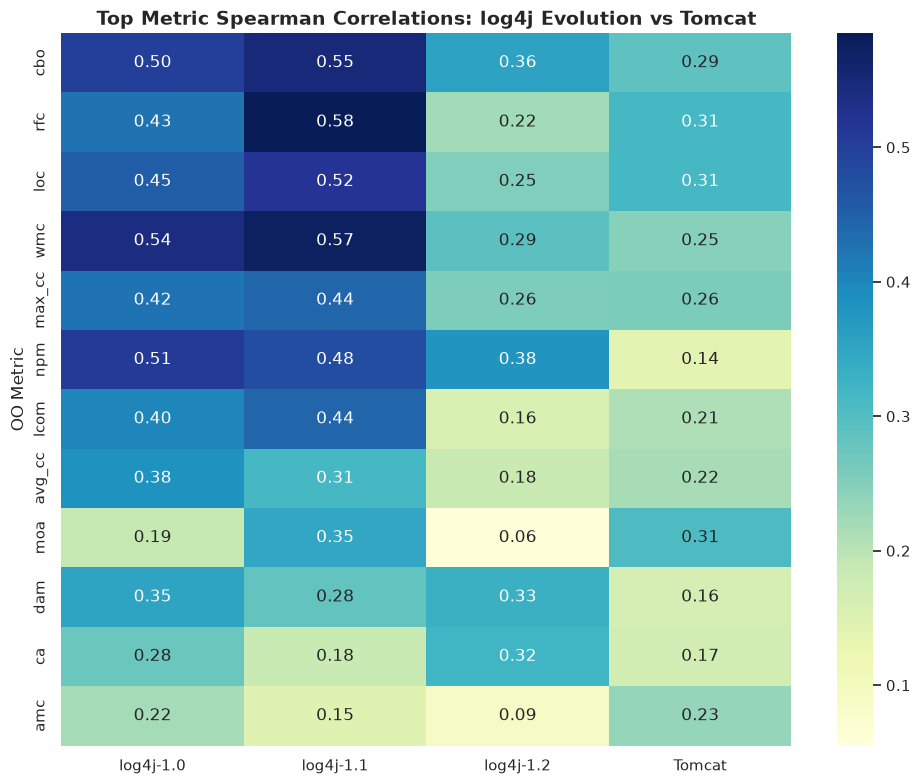

In [30]:
# Heatmap comparing log4j versions vs Tomcat
plt.figure(figsize=(10, 8))
sns.heatmap(
    cross_project_df[['log4j-1.0', 'log4j-1.1', 'log4j-1.2', 'Tomcat']].head(12), 
    annot=True, cmap='YlGnBu', fmt='.2f', cbar=True
)
plt.title('Top Metric Spearman Correlations: log4j Evolution vs Tomcat', fontsize=14, fontweight='bold')
plt.ylabel('OO Metric')
plt.tight_layout()
plt.show()

### 5.3 Cross-Project Analysis: Log4j Evolution vs. Tomcat

#### 1. General Trends & Key Similarities
* **Coupling & Size Dominance**  
  Coupling metrics (`rfc`: 0.31, `cbo`: 0.29) and size metrics (`loc`: 0.31, `wmc`: 0.25) remain among the top overall positive predictors of defects in Tomcat.  

* Software complexity fundamentals are domain-agnostic. In both projects, modules with high message-passing density (`rfc`) and larger volume (`loc`) increase cognitive burden and the statistical surface area for human error.

#### 2. Notable Differences Observed in the Heatmap
* **Lower Overall Correlation Magnitude** 
  * In `log4j-1.0` and `log4j-1.1`, metrics like `wmc` (0.54 to 0.57), `cbo` (0.50 to 0.55), and `npm` (0.48 to 0.51) exhibit strong correlations ($> 0.50$).
  * In Tomcat, almost all metric correlations drop into the moderate-to-weak range ($0.14 \le \rho \le 0.31$).
* **Drop in Public Interface Impact (`npm`)** 
  * Number of Public Methods (`npm`) drops from **0.51** in `log4j-1.0` down to **0.14** in Tomcat (the lowest in the heatmap).
* **Relative Strength of Aggregation (`moa`)**
  * Measure of Aggregation (`moa`) rises to **0.31** in Tomcat, tying with `rfc` and `loc` as one of Tomcat's strongest defect predictors, despite dropping to 0.06 in `log4j-1.2`.

#### 3. Software Engineering Reasons for the Differences
* **Architectural Scope & System Scale** 
  * `log4j` is a lightweight utility framework with tightly focused classes, meaning size and interface broadness (`npm`) directly mirror class usage and bug risk.
  * `tomcat` is a massive, multi-threaded enterprise web container. Defect drivers in complex servers are often driven by runtime concurrency, configuration issues, lifecycle management, and component aggregation (`moa`) rather than simple method counts (`npm`).
* **Code Base Maturity & Modular Boundaries** 
  * Enterprise applications like Tomcat employ design patterns (e.g., facade, adapter, interface abstraction) that split logic across many small public methods. This weakens the direct link between raw `npm` count and defect density.
* **Non-OO Factors in Tomcat** 
  * Due to Tomcat's scale, defects are frequently tied to integration boundaries and subsystem wiring rather than pure single-class Object-Oriented structural metrics.

#### 4. Conclusion on Generalizability
While structural metrics (`rfc`, `cbo`, `loc`) generalize well as **qualitative relative indicators** (i.e., higher complexity consistently means higher risk), **their predictive strength ($\rho$) diminishes in large-scale application servers**. Defect prediction models trained on small libraries (`log4j`) cannot be directly applied to complex enterprise systems (`tomcat`) without recalibration.

---

## Phase 6: Synthesis & Actionable Recommendations

### 6.1 Comprehensive Summary of Findings Across Versions & Projects

1. **Core Universal Drivers & Scale Sensitivity**
   * **Size & Coupling Dominance**  
     Metrics measuring volume (`wmc`, `loc`) and inter-class coupling (`cbo`, `rfc`) consistently act as the primary positive defect predictors across both `log4j` and `tomcat`.  

   * **Scale & Domain Dampening**  
     While structural metrics remain qualitatively predictive across systems, their rank correlation magnitudes ($\rho$) decrease significantly in larger, enterprise-scale applications like `tomcat` ($0.14 \le \rho \le 0.31$) compared to focused libraries like `log4j` ($\rho > 0.50$).

2. **Evolutionary Trajectory Across Log4j Releases**
   * **Expansion Peak in `log4j-1.1`**  
     Defect correlations peak during rapid framework expansion, where coupling (`rfc`: 0.58, `ce`: 0.55) and complexity (`wmc`: 0.57) directly catalyze bug density.  

   * **Stabilization Decay in `log4j-1.2`**  
     Refactoring and defect resolution in mature releases weaken raw metric-bug correlations (`rfc` drops to 0.22, `loc` to 0.25), proving that mature codebases shift bug drivers away from raw file size toward subtle runtime, synchronization, and configuration logic.  

   * **Interface & Dependency Stability**  
     Public API size (`npm`) and coupling (`cbo`) remain the most stable predictors throughout software evolution.

3. **Cohesion as a Protective Design Barrier**
   * Cohesion Among Methods (`cam`) consistently displays an inverse correlation with bugs ($\rho = -0.30$ in `log4j-1.0`), proving that classes adhering strictly to the **Single Responsibility Principle (SRP)** harbor fewer defects and resist structural complexity degradation.

4. **Limited Impact of Inheritance Depth**
   * Metrics like Depth of Inheritance Tree (`dit`) and Number of Children (`noc`) show near-zero correlations across all releases and projects ($\rho \approx 0.0$ to $0.15$), confirming that shallow inheritance hierarchies do not inherently drive defect proneness.

---

### 6.2 Actionable Guidelines for Software Engineering & Quality Assurance

#### 1. Automated Quality Gates in CI/CD Pipelines
* **Size & Coupling Guardrails**  
  Configure static analysis tools (e.g., SonarQube, PMD) to flag classes exceeding specific `wmc`, `cbo`, and `rfc` thresholds for mandatory peer review before merging.  

* **Public Interface Boundaries**  
  Monitor `npm` growth. Classes exposing excessively broad public interfaces should be refactored using design patterns (e.g., Facade or Adapter) to reduce client surface exposure.

#### 2. Risk-Based Test Resource Allocation
* **Prioritize High-Risk Modules**  
  Focus unit testing, integration testing, and automated test coverage on high-coupling (`cbo`, `rfc`) and high-aggregation (`moa`) classes, which statistically harbor the highest concentration of defects.  

* **Refactoring Strategy**  
  Prioritize refactoring monolithic classes exhibiting both high `loc` ($\rho = 0.91$ with `rfc`) and low cohesion (`cam`), as they represent the highest cognitive load and risk of regression errors during maintenance.

#### 3. Domain-Aware Defect Prediction Modeling
* When deploying Machine Learning or statistical models for defect prediction, standardizing features ($z$-score scaling) and filtering collinear features via VIF diagnostics are essential steps to avoid optimizer failures and unreliable coefficient estimates.  

* Defect prediction models must be recalibrated when moving between lightweight libraries (`log4j`) and complex application servers (`tomcat`), as absolute risk thresholds do not directly transfer across system domains.

---

## Phase 7: Questions From the Data

While statistical models and metric correlations reveal broad structural trends, diving deep into the empirical results uncovers several intriguing anomalies and open questions. The following are the questions that are raised after the analytical findings of the assignment.

---

### 7.1 Key Questions Raised by the Empirical Data

#### 1. The Threshold Effect: Is Code Complexity Linear or Step-Wise?
* **Observation**  
  Linear and rank correlations assume a monotonic relationship between metrics (like `loc` or `wmc`) and defect counts. However, in `log4j-1.2` and `tomcat`, many classes with high `wmc` had 0 reported bugs.  

* **Question**  
  Do Object-Oriented metrics exhibit a **non-linear threshold effect**? That is, is a class "safe" up to a critical complexity limit (e.g., `wmc` $< 20$), after which bug risk increases exponentially?  

* **Actionable Investigation**  
  Binning metric values into discrete risk tiers (Low, Medium, High, Extreme) using Decision Trees or Spline Regression to detect exact break-points rather than assuming continuous linearity.

#### 2. The Refactoring Paradox in `log4j-1.2`
* **Observation**  
  As `log4j` matured from version 1.1 to 1.2, average class sizes grew, yet metric-bug correlation coefficients dropped significantly (e.g., `rfc` fell from $0.58$ to $0.22$, and `loc` fell from $0.52$ to $0.25$).  

* **Question**  
  Does code refactoring reduce the *predictive power* of static metrics even if class sizes remain large?  

* **Actionable Investigation**  
  If a large class is exceptionally well-tested or stabilized over time, its raw size ceases to be an indicator of defects. This suggests that **Process Metrics** (e.g., code churn, number of revision commits, author density) may be far more predictive than static OO metrics in mature systems.

#### 3. Why Did Interface Exposure (`npm`) Collapse in Tomcat?
* **Observation**  
  Number of Public Methods (`npm`) was a top-3 predictor in `log4j-1.0` ($\rho = 0.51$) but plummeted to a negligible factor in `tomcat` ($\rho = 0.14$).  

* **Question**  
  How do architectural design patterns mask public API risk in enterprise frameworks?  

* **Actionable Investigation**  
  Application servers like Tomcat frequently employ the **Facade Pattern**, **Dependency Injection**, or **Interface Abstractions** and exposes many standardized, lightweight public getter/setter methods that add zero logical complexity. Static metrics treat all public methods equally, highlighting a core limitation in traditional OO metric design.

#### 4. Multicollinearity vs. Model Interpretability
* **Observation**  
  `loc`, `wmc`, `rfc`, and `max_cc` demonstrated extreme pairwise correlations ($\rho \ge 0.82 \text{ to } 0.91$).  

* **Question**  
  Are we measuring 10 distinct architectural properties, or simply measuring "Class Size" 10 different ways?  

* **Actionable Investigation**  
  Performing **Principal Component Analysis (PCA)** or **Factor Analysis** to reduce the 20+ OO metrics down to 3 underlying latent dimensions: *Volume*, *Dependency Coupling*, and *Cohesion*.

---

### 7.2 Summary Checklist of Data Limitations
To maintain analytical rigor, the following limitations inherent in the dataset must be acknowledged:  

1. **Defect Quantification**  
  The `bug` column represents a binary or integer count of historical post-release defects, but does not capture **bug severity** (e.g., critical security flaws vs. minor cosmetic issues).  

2. **Missing Process Context**  
  Static code snapshot metrics do not account for developer experience, time pressure, or historical code churn.  

3. **Domain Bias**  
  Results derived from Java-based open-source projects may not directly transfer to dynamically typed languages (e.g., Python, JavaScript) or functional programming paradigms.